In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.636992,-1.498940,-1.257052,0.379443,-3.062020,0
1,0.549560,-0.102243,-1.045320,2.134658,1.387735,0
2,-2.206857,-1.647062,-0.088947,1.758197,-0.115659,0
3,-0.687166,0.785646,0.086136,1.425224,-0.524041,1
4,-0.733175,0.019144,-2.318192,0.760160,-2.229618,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [8]:
import random
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [9]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [10]:
df1 = combined_sampling(df,0.5,0.5)

/var/folders/38/jww27k3s7pg8c5fv652czz3w0000gn/T/ipykernel_7380/4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [11]:
df2 = combined_sampling(df,0.5,0.5)

/var/folders/38/jww27k3s7pg8c5fv652czz3w0000gn/T/ipykernel_7380/4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [12]:
df3 = combined_sampling(df,0.5,0.5)

/var/folders/38/jww27k3s7pg8c5fv652czz3w0000gn/T/ipykernel_7380/4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [13]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col5', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')


In [14]:
df3

,col4,col2,target
88,-1.384643,2.666809,1
64,-0.381562,1.647700,1
70,1.333477,-0.258684,0
3,1.425224,0.785646,1
69,1.336704,1.090247,1
56,-2.313051,2.172897,1
96,2.705670,-0.242845,1
38,0.540536,1.830476,1
7,0.999677,-1.211966,0
26,1.487811,-3.015387,0


In [15]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [16]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [17]:
from sklearn.tree import plot_tree

[Text(0.375, 0.9285714285714286, 'x[0] <= -0.716\ngini = 0.449\nsamples = 50\nvalue = [33, 17]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[0] <= -1.128\ngini = 0.32\nsamples = 25\nvalue = [20, 5]'),
 Text(0.2708333333333333, 0.8571428571428572, 'True  '),
 Text(0.1111111111111111, 0.6428571428571429, 'x[1] <= -1.78\ngini = 0.43\nsamples = 16\nvalue = [11, 5]'),
 Text(0.05555555555555555, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.5, 'x[1] <= -0.588\ngini = 0.337\nsamples = 14\nvalue = [11, 3]'),
 Text(0.1111111111111111, 0.35714285714285715, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.2222222222222222, 0.35714285714285715, 'x[1] <= -0.143\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.16666666666666666, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2777777777777778, 0.21428571428571427, 'x[0] <= -1.322\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2222222222222222, 0.07142857142857142, 'gini = 

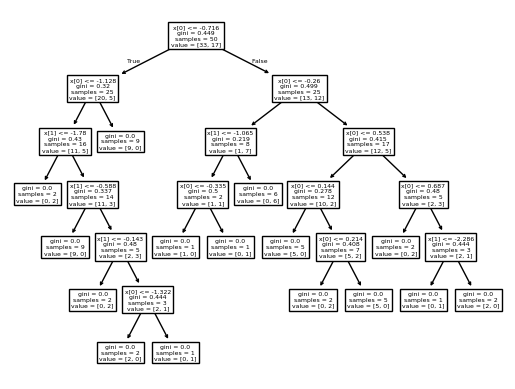

In [18]:
plot_tree(clf1)

[Text(0.3333333333333333, 0.9285714285714286, 'x[0] <= -0.443\ngini = 0.461\nsamples = 50\nvalue = [32, 18]'),
 Text(0.2222222222222222, 0.7857142857142857, 'gini = 0.0\nsamples = 24\nvalue = [24, 0]'),
 Text(0.2777777777777778, 0.8571428571428572, 'True  '),
 Text(0.4444444444444444, 0.7857142857142857, 'x[1] <= -1.071\ngini = 0.426\nsamples = 26\nvalue = [8, 18]'),
 Text(0.38888888888888884, 0.8571428571428572, '  False'),
 Text(0.3333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.5555555555555556, 0.6428571428571429, 'x[0] <= 0.859\ngini = 0.498\nsamples = 17\nvalue = [8, 9]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= 1.779\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.2222222222222222, 0.35714285714285715, 'x[1] <= 0.208\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.1111111111111111, 0.21428571428571427, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.3333333333333333, 0.21428571428571427, 'x[1] <= 0.414\ngini = 0.375\nsampl

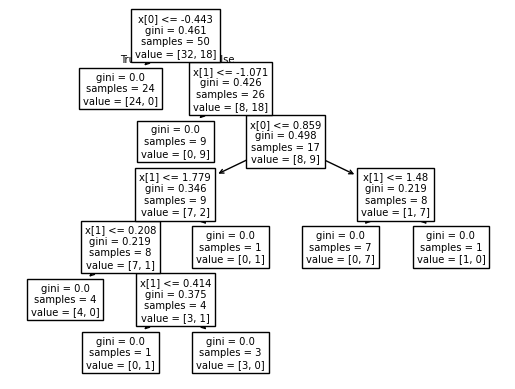

In [19]:
plot_tree(clf2)

[Text(0.5, 0.8333333333333334, 'x[1] <= 0.635\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.25, 0.5, 'x[0] <= 2.42\ngini = 0.137\nsamples = 27\nvalue = [25, 2]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 25\nvalue = [25, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.5, 'x[0] <= 2.445\ngini = 0.159\nsamples = 23\nvalue = [2, 21]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

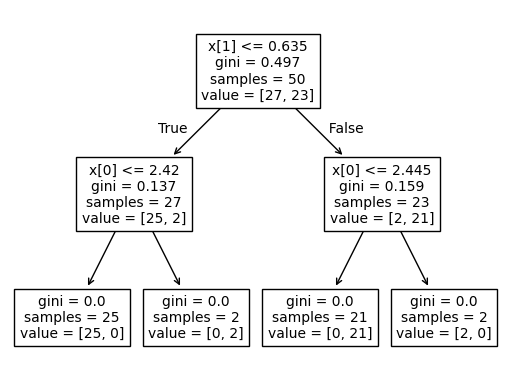

In [20]:
plot_tree(clf3)

In [21]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/opt/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/opt/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [23]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/opt/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [24]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
60,-0.390068,1.502812,-0.455220,-0.994058,-1.946291,1
2,-2.206857,-1.647062,-0.088947,1.758197,-0.115659,0
23,-2.687289,-2.909589,-1.694048,-0.426301,-2.326753,0
28,-0.066188,-0.261680,-0.065705,2.995303,2.258800,0
1,0.549560,-0.102243,-1.045320,2.134658,1.387735,0
38,-2.777681,1.830476,-0.748703,0.540536,1.596114,1
87,1.823646,1.019329,-0.826602,2.576186,1.988779,0
3,-0.687166,0.785646,0.086136,1.425224,-0.524041,1
91,0.146223,0.545800,0.155300,-0.166736,-2.904471,1
87,1.823646,1.019329,-0.826602,2.576186,1.988779,0
